# Feature Scores

> Utility functions for mapping fastai learner outputs and computing interpretable scores on images.

This module groups simple scores computed directly on pixels, making it possible to compare the representations learned by the model with readable visual properties: intensity, color, spatial structure, and frequencies.

In [ ]:
#| default_exp feature_scores

## Module Organization

For now, all functions remain in a single notebook, `02_feature_scores.ipynb`. This is easier to maintain while the catalog is small and the functions share the same image-reading helpers.

Splitting into submodules may become relevant later if a family grows substantially, for example `feature_scores.frequency`, `feature_scores.color`, or `feature_scores.spatial`. Until then, the chosen tradeoff is a single module with sections and one registry per category.

In [ ]:
#| export
from __future__ import annotations

import math
from collections.abc import Callable, Iterable, Sequence
from pathlib import Path
from typing import Any, Literal

import torch
import torch.fft
from torch import Tensor
from torchvision.io import ImageReadMode, read_image
import torchvision.transforms.functional as TF

try:
    from tqdm.auto import tqdm
except ModuleNotFoundError:  # pragma: no cover - fallback for minimal environments
    def tqdm(iterable=None, *args, **kwargs):
        return iterable if iterable is not None else []

ErrorPolicy = Literal["previous", "nan", "raise"]
ImagePath = str | Path
ScoreFn = Callable[[Sequence[ImagePath]], list[float]]


def _as_paths(image_paths: Iterable[ImagePath]) -> list[Path]:
    return [Path(path) for path in image_paths]


def _read_grayscale_image(image_path: ImagePath, image_size: tuple[int, int] | None = None) -> Tensor:
    img = read_image(str(image_path), mode=ImageReadMode.GRAY).float() / 255.0
    if image_size is not None:
        img = TF.resize(img, list(image_size), antialias=True)
    if img.shape[0] > 1:
        img = TF.rgb_to_grayscale(img[:3])
    return img


def _read_rgb_image(image_path: ImagePath, image_size: tuple[int, int] | None = None) -> Tensor:
    img = read_image(str(image_path), mode=ImageReadMode.RGB).float() / 255.0
    if image_size is not None:
        img = TF.resize(img, list(image_size), antialias=True)
    return img


def _handle_score_error(error: Exception, image_path: Path, last_valid_score: float, on_error: ErrorPolicy) -> float:
    if on_error == "raise":
        raise error
    if on_error == "nan":
        return float("nan")
    if on_error == "previous":
        print(f"Error for {image_path}: {error} -> assigning previous score: {last_valid_score:.4f}")
        return last_valid_score
    raise ValueError(f"Unknown error policy: {on_error!r}")


def _compute_scores(
    image_paths: Iterable[ImagePath],
    scorer: Callable[[Path], float],
    desc: str,
    on_error: ErrorPolicy = "previous",
) -> list[float]:
    scores: list[float] = []
    last_valid_score = 0.0

    for image_path in tqdm(_as_paths(image_paths), desc=desc):
        try:
            score = float(scorer(image_path))
            if not math.isfinite(score):
                raise ValueError(f"Non-finite score: {score}")
            scores.append(score)
            last_valid_score = score
        except Exception as error:
            scores.append(_handle_score_error(error, image_path, last_valid_score, on_error))

    return scores


def _require_pandas():
    try:
        import pandas as pd
    except ModuleNotFoundError as error:  # pragma: no cover - environment dependent
        raise ModuleNotFoundError("pandas is required for tabular feature-score outputs") from error
    return pd

## Mapping Learner Outputs {#feature-scores-mapping}

Before comparing feature scores with model predictions, the alignment between learner outputs and the original files must be preserved. The following function keeps the order produced by `get_preds(..., reorder=False)` and reconstructs a provenance table.

In [ ]:
#| export
def _class_indices(values: Tensor) -> Tensor:
    if values.ndim > 1:
        return values.argmax(dim=-1)
    return values


def _class_names(indices: Tensor, vocab: Any) -> list[str] | None:
    if vocab is None:
        return None
    return [str(vocab[int(idx)]) for idx in indices]


def map_learner_predictions(
    learn: Any,
    ds_idxs: Sequence[int] = (0, 1),
    include_predictions: bool = False,
):
    """Map fastai learner predictions back to their source files.

    Parameters
    ----------
    learn : fastai Learner
        Learner whose dataloaders expose the original dataset items.
    ds_idxs : sequence of int, default=(0, 1)
        Dataset indices to map. In fastai, 0 is usually train and 1 is valid.
    include_predictions : bool, default=False
        When True, append target and prediction columns to the provenance table.

    Returns
    -------
    tuple[Tensor, pandas.DataFrame]
        Concatenated inputs and a DataFrame aligned row-by-row with these inputs.
    """
    pd = _require_pandas()
    all_inputs: list[Tensor] = []
    all_dfs = []
    vocab = getattr(learn.dls, "vocab", None)

    for ds_idx in ds_idxs:
        inputs, preds, targets = learn.get_preds(ds_idx=ds_idx, with_input=True, reorder=False)
        dl = learn.dls[ds_idx]
        indices = list(dl.get_idxs())
        original_files = list(dl.dataset.items)
        path_mapping = [original_files[idx] for idx in indices]

        set_name = "Train" if ds_idx == 0 else "Valid" if ds_idx == 1 else f"Dataset {ds_idx}"
        mapping_df = pd.DataFrame(
            {
                "Set": set_name,
                "Original_Dataset_Index": indices,
                "Source_File_Path": [str(path) for path in path_mapping],
            }
        )

        if include_predictions:
            predicted_class_indices = _class_indices(preds).cpu()
            real_target_indices = _class_indices(targets).cpu()
            predicted_class_names = _class_names(predicted_class_indices, vocab)
            mapping_df["Real_Target_ID"] = real_target_indices.numpy()
            mapping_df["Predicted_Class_ID"] = predicted_class_indices.numpy()
            if predicted_class_names is not None:
                mapping_df["Predicted_Class_Name"] = predicted_class_names
            mapping_df["Correct_Prediction"] = (
                real_target_indices.numpy() == predicted_class_indices.numpy()
            )

        all_inputs.append(inputs)
        all_dfs.append(mapping_df)

    return torch.cat(all_inputs, dim=0), pd.concat(all_dfs, ignore_index=True)


# Backward-compatible alias for the original helper name.
mapping = map_learner_predictions

## Global Intensity Scores {#feature-scores-intensity}

These scores summarize the grayscale distribution across the whole image. They are useful for detecting brightness, contrast, or statistical asymmetry effects that can influence a classifier without directly corresponding to semantic structure.

In [ ]:
#| export
def compute_brightness_scores(image_paths: Iterable[ImagePath], on_error: ErrorPolicy = "previous") -> list[float]:
    """Compute mean grayscale intensity for each image."""
    return _compute_scores(
        image_paths,
        lambda path: _read_grayscale_image(path).mean().item(),
        desc="Computing brightness",
        on_error=on_error,
    )


def compute_variance_scores(image_paths: Iterable[ImagePath], on_error: ErrorPolicy = "previous") -> list[float]:
    """Compute grayscale variance as a global contrast score."""
    return _compute_scores(
        image_paths,
        lambda path: _read_grayscale_image(path).var().item(),
        desc="Computing variance / contrast",
        on_error=on_error,
    )


def compute_skewness_scores(image_paths: Iterable[ImagePath], on_error: ErrorPolicy = "previous") -> list[float]:
    """Compute grayscale skewness for each image."""
    def scorer(path: Path) -> float:
        img = _read_grayscale_image(path)
        mean = img.mean()
        std = img.std()
        if std <= 1e-6:
            return 0.0
        return (((img - mean) ** 3).mean() / (std**3)).item()

    return _compute_scores(image_paths, scorer, desc="Computing skewness", on_error=on_error)

## Color Scores {#feature-scores-color}

These scores use the RGB channels. They should be interpreted carefully: they can capture dataset, lighting, makeup, or preprocessing effects as much as cues that are truly related to the class.

In [ ]:
#| export
def compute_color_covariance_scores(image_paths: Iterable[ImagePath], on_error: ErrorPolicy = "previous") -> list[float]:
    """Compute covariance between red and blue channels."""
    def scorer(path: Path) -> float:
        img = _read_rgb_image(path)
        red_channel = img[0].flatten()
        blue_channel = img[2].flatten()
        cov_matrix = torch.cov(torch.stack([red_channel, blue_channel]))
        return cov_matrix[0, 1].item()

    return _compute_scores(image_paths, scorer, desc="Computing red/blue covariance", on_error=on_error)


def compute_redness_dominance_scores(image_paths: Iterable[ImagePath], on_error: ErrorPolicy = "previous") -> list[float]:
    """Compute red-channel dominance relative to green and blue channels."""
    def scorer(path: Path) -> float:
        img = _read_rgb_image(path)
        red_mean = img[0].mean()
        green_mean = img[1].mean()
        blue_mean = img[2].mean()
        return (red_mean / (green_mean + blue_mean + 1e-6)).item()

    return _compute_scores(image_paths, scorer, desc="Computing red dominance", on_error=on_error)

## Spatial and Regional Scores {#feature-scores-spatial}

These scores preserve positional information: left-right symmetry, top/bottom ratio, central texture, eye-band contrast, and edge activity in the jaw region. They are closer to visual hypotheses about faces, so they are less generic than global scores.

In [ ]:
#| export
def compute_symmetry_scores(image_paths: Iterable[ImagePath], on_error: ErrorPolicy = "previous") -> list[float]:
    """Compute horizontal symmetry error. Lower values mean stronger symmetry."""
    def scorer(path: Path) -> float:
        img = _read_grayscale_image(path)
        img_flipped = torch.flip(img, dims=[2])
        return torch.abs(img - img_flipped).mean().item()

    return _compute_scores(image_paths, scorer, desc="Computing symmetry", on_error=on_error)


def compute_top_bottom_ratio_scores(image_paths: Iterable[ImagePath], on_error: ErrorPolicy = "previous") -> list[float]:
    """Compute mean brightness ratio between upper and lower halves."""
    def scorer(path: Path) -> float:
        img = _read_grayscale_image(path)
        h = img.shape[1]
        top_half = img[:, : h // 2, :].mean()
        bottom_half = img[:, h // 2 :, :].mean()
        return (top_half / (bottom_half + 1e-6)).item()

    return _compute_scores(image_paths, scorer, desc="Computing top/bottom ratio", on_error=on_error)


def compute_center_texture_scores(image_paths: Iterable[ImagePath], on_error: ErrorPolicy = "previous") -> list[float]:
    """Compute grayscale variance in the central crop of each image."""
    def scorer(path: Path) -> float:
        img = _read_grayscale_image(path)
        h, w = img.shape[1], img.shape[2]
        center_region = img[:, h // 4 : 3 * h // 4, w // 4 : 3 * w // 4]
        return center_region.var().item()

    return _compute_scores(image_paths, scorer, desc="Computing central texture", on_error=on_error)


def compute_eye_region_contrast_scores(image_paths: Iterable[ImagePath], on_error: ErrorPolicy = "previous") -> list[float]:
    """Compute grayscale variance in a horizontal band roughly matching the eye region."""
    def scorer(path: Path) -> float:
        img = _read_grayscale_image(path)
        h = img.shape[1]
        eye_region = img[:, int(h * 0.3) : int(h * 0.5), :]
        return eye_region.var().item()

    return _compute_scores(image_paths, scorer, desc="Computing eye contrast", on_error=on_error)


def compute_jaw_texture_scores(image_paths: Iterable[ImagePath], on_error: ErrorPolicy = "previous") -> list[float]:
    """Compute lower-face edge activity from adjacent-pixel intensity differences."""
    def scorer(path: Path) -> float:
        img = _read_grayscale_image(path)
        h = img.shape[1]
        jaw_region = img[:, int(h * 0.7) :, :]
        diff_x = torch.abs(jaw_region[:, :, 1:] - jaw_region[:, :, :-1]).mean()
        diff_y = torch.abs(jaw_region[:, 1:, :] - jaw_region[:, :-1, :]).mean()
        return (diff_x + diff_y).item()

    return _compute_scores(image_paths, scorer, desc="Computing jaw texture", on_error=on_error)

## Frequency Scores and Thresholds {#feature-scores-frequency}

Frequency scores move into the Fourier domain to measure the proportion of energy carried by high frequencies. The Otsu helper remains separate: it does not directly produce a dataset score, but can be used to build scores based on segmentation or foreground/background separation.

In [ ]:
#| export
def compute_fft_scores(
    image_paths: Iterable[ImagePath],
    radius: int = 30,
    image_size: tuple[int, int] = (200, 200),
    on_error: ErrorPolicy = "previous",
) -> list[float]:
    """Compute the high-frequency energy ratio for each image.

    The central disk of radius `radius` is treated as low frequency. The score is
    the remaining high-frequency energy divided by total FFT magnitude energy.
    """
    def scorer(path: Path) -> float:
        img = _read_grayscale_image(path, image_size=image_size)
        if img.ndim == 3:
            if img.shape[0] > 1:
                img = TF.rgb_to_grayscale(img[:3])
            img = img.squeeze(0)
        else:
            img = img.squeeze()
        if img.ndim != 2:
            raise ValueError(f"Expected a 2D grayscale image for FFT, got shape {tuple(img.shape)}")

        fshift = torch.fft.fftshift(torch.fft.fft2(img))
        magnitude_spectrum = torch.abs(fshift)

        rows, cols = img.shape
        crow, ccol = rows // 2, cols // 2
        y = torch.arange(-crow, rows - crow, device=img.device).view(-1, 1)
        x = torch.arange(-ccol, cols - ccol, device=img.device).view(1, -1)
        low_frequency_mask = x**2 + y**2 <= radius**2

        total_energy = magnitude_spectrum.sum()
        if total_energy <= 0:
            return 0.0
        low_frequency_energy = magnitude_spectrum[low_frequency_mask].sum()
        high_frequency_energy = total_energy - low_frequency_energy
        return (high_frequency_energy / total_energy).item()

    return _compute_scores(image_paths, scorer, desc="Computing FFT scores", on_error=on_error)


def find_otsu_threshold(im_gray: Tensor) -> int:
    """Find Otsu's threshold for a grayscale image tensor.

    Accepts images scaled either in `[0, 1]` or `[0, 255]`.
    """
    img = im_gray.detach().float()
    if img.numel() == 0:
        return 0
    if img.max() <= 1:
        img = img * 255
    img = img.clamp(0, 255)

    hist = torch.histc(img, bins=256, min=0, max=255)
    if hist.sum() <= 0:
        return 0
    p = hist / hist.sum()
    intensities = torch.arange(256, dtype=torch.float32, device=img.device)

    max_sigma_b = torch.tensor(0.0, device=img.device)
    optimal_threshold = 0
    for threshold in range(1, 255):
        w0 = p[:threshold].sum()
        w1 = p[threshold:].sum()
        if w0 == 0 or w1 == 0:
            continue
        mu0 = (intensities[:threshold] * p[:threshold]).sum() / w0
        mu1 = (intensities[threshold:] * p[threshold:]).sum() / w1
        sigma_b = w0 * w1 * (mu0 - mu1) ** 2
        if sigma_b > max_sigma_b:
            max_sigma_b = sigma_b
            optimal_threshold = threshold

    return optimal_threshold

## Exported Catalog {#feature-scores-catalog}

The registry below provides a common API for listing available scores or computing a complete table. Keys remain in English for the Python API, while the notebook sections document the intent of each category.

In [ ]:
#| export
FEATURE_SCORE_CATEGORIES: dict[str, dict[str, ScoreFn]] = {
    "intensity": {
        "brightness": compute_brightness_scores,
        "variance": compute_variance_scores,
        "skewness": compute_skewness_scores,
    },
    "color": {
        "color_covariance_red_blue": compute_color_covariance_scores,
        "redness_dominance": compute_redness_dominance_scores,
    },
    "spatial": {
        "symmetry_error": compute_symmetry_scores,
        "top_bottom_brightness_ratio": compute_top_bottom_ratio_scores,
        "center_texture": compute_center_texture_scores,
        "eye_region_contrast": compute_eye_region_contrast_scores,
        "jaw_texture": compute_jaw_texture_scores,
    },
    "frequency": {
        "fft_high_frequency_ratio": compute_fft_scores,
    },
}


def available_feature_scores() -> dict[str, list[str]]:
    """Return available feature-score names grouped by category."""
    return {category: list(scores) for category, scores in FEATURE_SCORE_CATEGORIES.items()}


def _flatten_feature_scores() -> dict[str, ScoreFn]:
    return {
        score_name: score_fn
        for category_scores in FEATURE_SCORE_CATEGORIES.values()
        for score_name, score_fn in category_scores.items()
    }


def compute_feature_score_table(
    image_paths: Iterable[ImagePath],
    score_names: Sequence[str] | None = None,
    on_error: ErrorPolicy = "previous",
):
    """Compute selected feature scores and return them in a pandas DataFrame.

    Parameters
    ----------
    image_paths : iterable of str or Path
        Images to score.
    score_names : sequence of str, optional
        Names from `available_feature_scores()`. When omitted, all scores are computed.
    on_error : {"previous", "nan", "raise"}, default="previous"
        Error handling policy for unreadable images.
    """
    pd = _require_pandas()
    paths = _as_paths(image_paths)
    flat_scores = _flatten_feature_scores()
    selected_names = list(flat_scores) if score_names is None else list(score_names)

    unknown_scores = sorted(set(selected_names) - set(flat_scores))
    if unknown_scores:
        raise KeyError(f"Unknown feature scores: {unknown_scores}")

    data: dict[str, Any] = {"Source_File_Path": [str(path) for path in paths]}
    for score_name in selected_names:
        data[score_name] = flat_scores[score_name](paths, on_error=on_error)

    return pd.DataFrame(data)

## PETS Example {#feature-scores-example}

The goal of this example is simply to verify, with a public fastai dataset, that the scores compute correctly on real images.

Only the first 8 images returned by `get_image_files` are used so the documentation remains quick to generate. The idea is not to analyze the full dataset here, but to show concrete API usage and the expected outputs.

In [ ]:
from pathlib import Path

from fastai.vision.all import URLs, get_image_files, untar_data
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
#| output: false
# Import a dataset (example: fastai PETS).
pets_path = untar_data(URLs.PETS) / "images"
pet_images = list(get_image_files(pets_path))[:8]

In [ ]:
len(pet_images), [path.name for path in pet_images]

(8,
 ['Egyptian_Mau_167.jpg',
  'pug_52.jpg',
  'basset_hound_112.jpg',
  'Siamese_193.jpg',
  'shiba_inu_122.jpg',
  'Siamese_53.jpg',
  'Birman_167.jpg',
  'leonberger_6.jpg'])

In [ ]:
# Disable progress bars in this documentation example to keep the rendered output compact.
_tqdm = tqdm
try:
    tqdm = lambda iterable=None, *args, **kwargs: iterable if iterable is not None else []
    pets_scores = compute_feature_score_table(
        pet_images,
        score_names=[
            "brightness",
            "variance",
            "redness_dominance",
            "symmetry_error",
            "fft_high_frequency_ratio",
        ],
        on_error="raise",
    )
finally:
    tqdm = _tqdm

pets_scores_display = pets_scores.copy()
pets_scores_display["image_name"] = pets_scores_display["Source_File_Path"].map(lambda path: Path(path).name)
pets_scores_display = pets_scores_display.drop(columns="Source_File_Path")
pets_scores_display = pets_scores_display[["image_name", *[col for col in pets_scores_display.columns if col != "image_name"]]]
pets_scores_display.round(4)

,image_name,brightness,variance,redness_dominance,symmetry_error,fft_high_frequency_ratio
0,Egyptian_Mau_167.jpg,0.3457,0.0200,0.2308,0.1133,0.5556
1,pug_52.jpg,0.3001,0.0636,0.7870,0.1703,0.4728
2,basset_hound_112.jpg,0.6347,0.0509,0.4880,0.1451,0.4010
3,Siamese_193.jpg,0.3674,0.0227,0.7101,0.1142,0.5191
4,shiba_inu_122.jpg,0.4622,0.0458,0.5784,0.1845,0.4383
5,Siamese_53.jpg,0.4481,0.0845,0.5633,0.2559,0.4944
6,Birman_167.jpg,0.4343,0.0551,0.5348,0.2271,0.4769
7,leonberger_6.jpg,0.5540,0.0619,0.5800,0.2751,0.4845


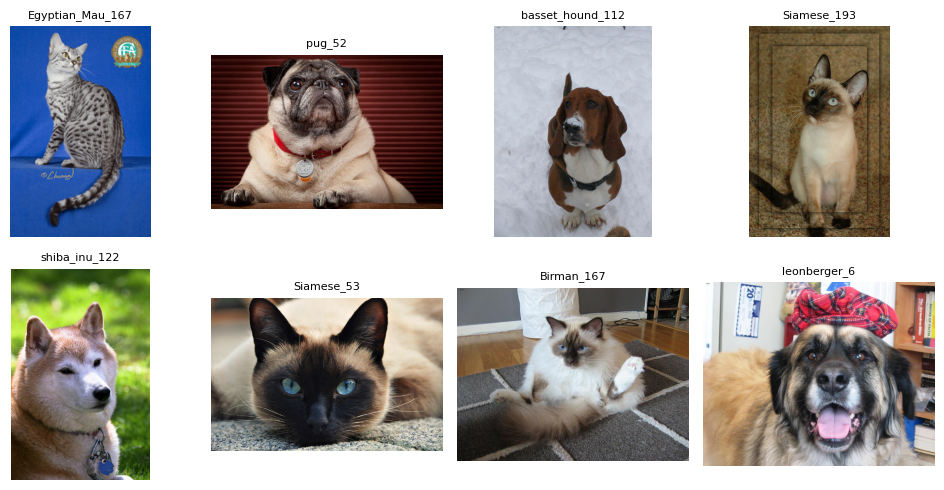

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for ax, image_path in zip(axes.flat, pet_images):
    ax.imshow(Image.open(image_path))
    ax.set_title(image_path.stem[:18], fontsize=8)
    ax.axis("off")

plt.tight_layout()

The values obtained here are not interpreted as model explanations. They are used to verify that each score family produces a numeric measurement on real images:

- `brightness` and `variance` describe global intensity;
- `redness_dominance` comes from the color family;
- `symmetry_error` comes from the spatial family;
- `fft_high_frequency_ratio` comes from the frequency family.

To connect these scores to a trained model, the next step is to use `map_learner_predictions` to retrieve paths in the exact order of the learner predictions.